I. Mô hình linear regression
1. Khái niệm
- Là một phương pháp trong Machine Learning dùng để dự đoán giá trị liên tục dựa trên mối quan hệ tuyến tính giữa các biến đầu vào và biến đầu ra
    - Mô hình toán học: Giả sử cân nặng là một hàm bậc nhất theo chiều cao:
$$y \approx f(x) = \hat{y} = w_1 x + w_0$$
Trong đó: $w_1$ là trọng số (weight), $w_0$ là độ lệch (bias).
- Hàm mất mát (Loss Function): Giải thích việc tìm nghiệm chính là tìm điểm làm cực tiểu hàm mất mát (sai số bình phương):
$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y_i - \mathbf{x}_i \mathbf{w})^2 = \frac{1}{2} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2$$
- Công thức nghiệm: Nêu kết quả cuối cùng của việc lấy đạo hàm và giải phương trình đạo hàm bằng 0:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$



import thư viện

In [3]:
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt


Dữ liệu chiều cao và cân nặng. Lấy mốc chiều cao 155 và 160 để kiếm thử

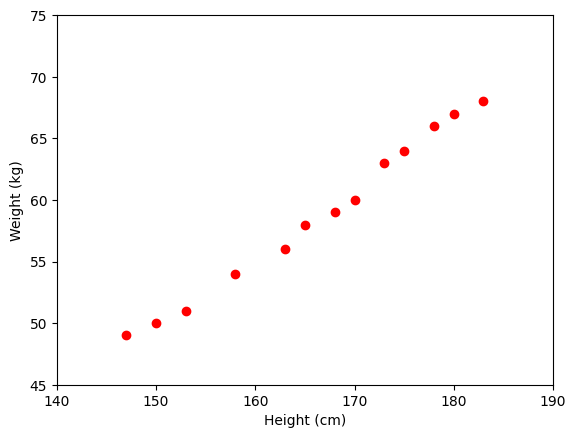

In [11]:
X = np.array([[147,150,153,158,163,165,168,170,173,175,178,180,183]]).T
y = np.array([[49,50,51,54,56,58,59,60,63,64,66,67,68]]).T
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()



Tạo ma trận Xbar

In [12]:
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

Tính nghiệm Linear Regression

In [13]:
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ',w)


w =  [[-34.12658585]
 [  0.55878207]]


In [14]:
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

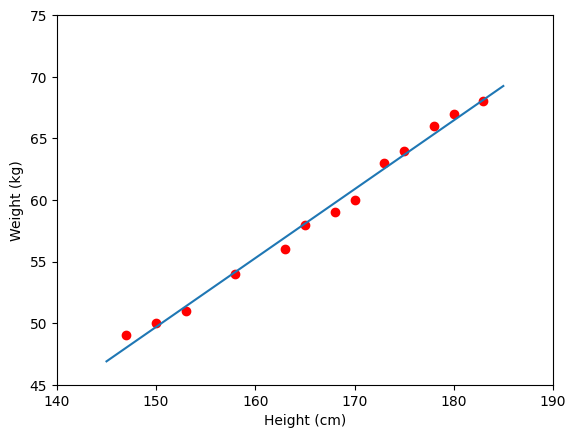

In [15]:
plt.plot(X.T, y.T, 'ro')   
plt.plot(x0, y0)              
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

Dự đoán 

In [16]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.48 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.28 (kg), real number: 56 (kg)


Dùng thư viện sklearn

In [17]:
from sklearn import linear_model

regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y)

print(regr.coef_)

[[-34.12658585   0.55878207]]


=> Thu được kết quả giống như cách tính ở trên

II. Ưu và nhược điểm
1. Ưu điểm:
    - Đơn giản
    - Dễ hiểu
    - Tính toán nhanh
    - Có nghiệm chính xác
2. Nhược điểm:
    - Nhạy với outlier: 
    Ví dụ 150 cm -> 80 kg sẽ làm lệch đường regression
    - Không mô tả được quan hệ phức tạp:
    Ví dụ: Quan hệ phi tuyến tính
II. Khi nào nên dùng Linear Regression
    - Dữ liệu có xu hướng tuyến tính
    - Dự đoán giá trị liên tục
Ví dụ:
    - giá nhà
    - nhiệt độ
    

III. Bài tập

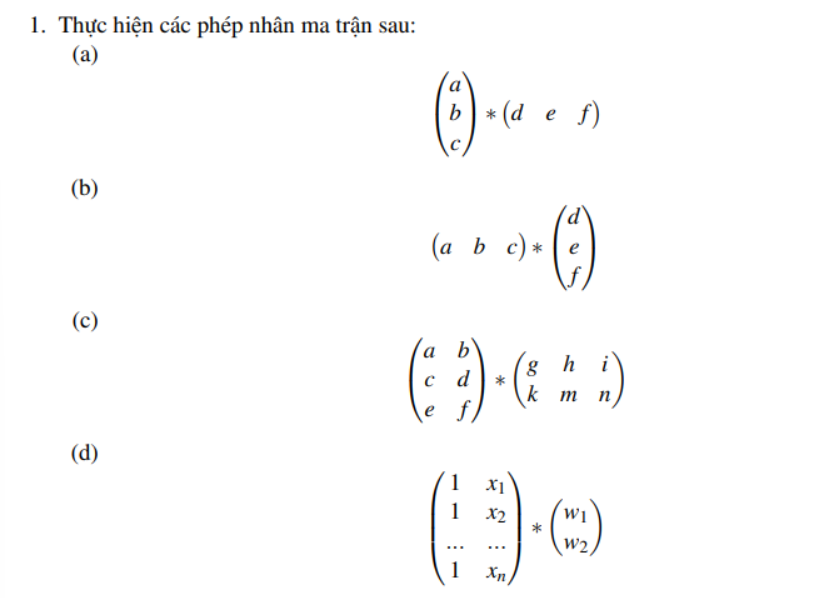

(a)$$\begin{pmatrix} a \\ b \\ c \end{pmatrix} * \begin{pmatrix} d & e & f \end{pmatrix} = 
\begin{pmatrix} 
ad & ae & af \\ 
bd & be & bf \\ 
cd & ce & cf 
\end{pmatrix}$$(b)$$\begin{pmatrix} a & b & c \end{pmatrix} * \begin{pmatrix} d \\ e \\ f \end{pmatrix} = ad + be + cf$$(c)$$\begin{pmatrix} a & b \\ c & d \\ e & f \end{pmatrix} * \begin{pmatrix} g & h & i \\ k & m & n \end{pmatrix} = 
\begin{pmatrix} 
ag+bk & ah+bm & ai+bn \\ 
cg+dk & ch+dm & ci+dn \\ 
eg+fk & eh+fm & ei+fn 
\end{pmatrix}$$(d)$$\begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \dots & \dots \\ 1 & x_n \end{pmatrix} * \begin{pmatrix} w_1 \\ w_2 \end{pmatrix} = 
\begin{pmatrix} 
w_1 + w_2 x_1 \\ 
w_1 + w_2 x_2 \\ 
\dots \\ 
w_1 + w_2 x_n 
\end{pmatrix}$$

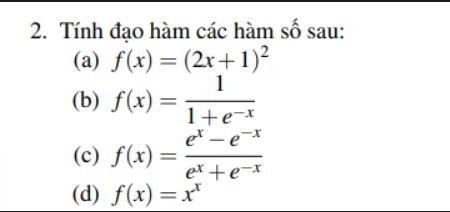

(a) $$f'(x) = 2(2x+1) \cdot 2 = 8x + 4$$

(b) $$f'(x) = \frac{-( -e^{-x} )}{(1+e^{-x})^2} = \frac{e^{-x}}{(1+e^{-x})^2} = f(x)(1 - f(x))$$

(c) $$f'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 = 1 - f(x)^2$$

(d)
Lấy $\ln$ hai vế: 

$$\ln f(x) = x \ln x$$

Đạo hàm hai vế: 

$$\frac{f'(x)}{f(x)} = \ln x + x \cdot \frac{1}{x} = \ln x + 1$$

-> $$f'(x) = x^x(\ln x + 1)$$

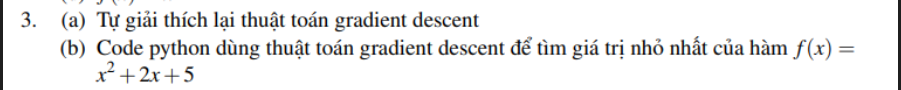

(a) Giải thích thuật toán:Gradient Descent là thuật toán tối ưu hóa lặp để tìm điểm cực tiểu của hàm số. Thuật toán bắt đầu từ một điểm $x$ khởi tạo ngẫu nhiên, sau đó cập nhật $x$ liên tục bằng cách bước lùi ngược hướng với đạo hàm (gradient) tại điểm đó. Kích thước mỗi bước nhảy được kiểm soát bởi tham số learning rate ($\eta$):$$x_{new} = x_{old} - \eta \cdot \nabla f(x_{old})$$
(b)


In [18]:
# Đạo hàm của hàm số là: f'(x) = 2x + 2
def grad(x):
    return 2 * x + 2

def gradient_descent(x_init, learning_rate, epochs):
    x = x_init
    for _ in range(epochs):
        x = x - learning_rate * grad(x)
    return x

# Khởi tạo x = 5, learning_rate = 0.1, lặp 100 lần
x_min = gradient_descent(x_init=5, learning_rate=0.1, epochs=100)
print(f"Giá trị x làm hàm nhỏ nhất là: {x_min:.5f}")

Giá trị x làm hàm nhỏ nhất là: -1.00000


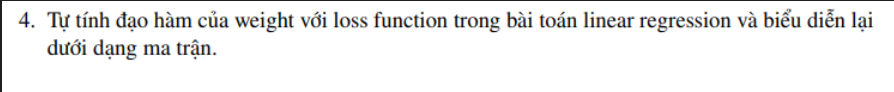

Hàm mất mát (Mean Squared Error) dạng ma trận:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 = \frac{1}{2} (\mathbf{X}\mathbf{w} - \mathbf{y})^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$Khai triển biểu thức:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} (\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{w}^T\mathbf{X}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{y}^T\mathbf{y})$$Vì $\mathbf{y}^T\mathbf{X}\mathbf{w}$ là một số vô hướng nên nó bằng chuyển vị của chính nó $\mathbf{w}^T\mathbf{X}^T\mathbf{y}$, ta gộp lại:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} (\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{y}^T\mathbf{y})$$Lấy đạo hàm theo vector trọng số $\mathbf{w}$:$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{2} (2\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{X}^T\mathbf{y}) = \mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y}$$Ghi gọn lại dưới dạng ma trận:$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$

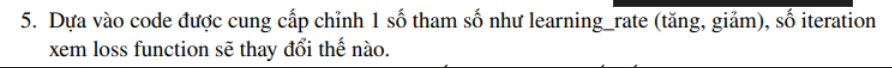

1. Thay đổi Learning Rate:
    - Tăng quá lớn: Gradient Descent bước những bước quá dài, có thể nhảy vọt qua điểm cực tiểu. Hàm loss sẽ dao động lên xuống rất mạnh, thậm chí ngày càng tăng (thuật toán bị phân kỳ).
    - Giảm quá nhỏ: Thuật toán di chuyển quá cẩn thận, mất rất nhiều thời gian để hội tụ. Hàm loss giảm rất chậm và nếu hàm phức tạp, thuật toán có nguy cơ mắc kẹt ở cực tiểu địa phương (local minimum).
    - Vừa phải: Hàm loss giảm dần đều đặn qua mỗi vòng lặp và hội tụ ổn định về mức tối thiểu.

2. Thay đổi số vòng lặp:
    - Quá ít: Thuật toán phải dừng lại trước khi chạm đến điểm cực tiểu (chưa hội tụ). Giá trị hàm loss vẫn còn cao và model dự đoán chưa chính xác.
    - Quá nhiều: Khi thuật toán đã chạm đáy cực tiểu, hàm loss sẽ gần như không thay đổi nữa. Chạy thêm vòng lặp lúc này chỉ làm lãng phí thời gian và tài nguyên máy tính.

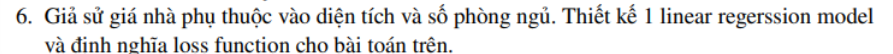

1. Thiết kế Model:
Giả sử $y$ là giá nhà, $x_1$ là diện tích, và $x_2$ là số phòng ngủ. Bài toán này có nhiều hơn một biến đầu vào, nên ta dùng Hồi quy tuyến tính đa biến (Multiple Linear Regression).

Mô hình dự đoán có dạng:
    
$$\hat{y} = w_1x_1 + w_2x_2 + w_0$$
    
*Trong đó:* * $w_1, w_2$ là trọng số (weights) của đặc trưng diện tích và số phòng ngủ.
* $w_0$ là độ lệch (bias).

Viết gọn dưới dạng ma trận: $\mathbf{\hat{y}} = \mathbf{X}\mathbf{w}$

2. Định nghĩa Loss Function:
Ta vẫn sử dụng hàm Sai số toàn phương trung bình (Mean Squared Error - MSE) để đo lường chênh lệch giữa giá thực tế và giá dự đoán:
    
$$\mathcal{L}(\mathbf{w}) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 = \frac{1}{2N} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$$